In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import os
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from anndata import AnnData
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from scipy.stats import pearsonr
from scipy.stats import spearmanr

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch

import itertools
import scipy
import statsmodels.stats.multitest
import matplotlib as mpl
import pathlib

import common_data
import common_plots
import factor_interpretation as fi

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_cmap(ax):
    return plt.get_cmap(ax.ax_heatmap.collections[0].get_cmap().name).name

def plot_pc_cat_assoc(pc_corrs):
    pc_corrs = pc_corrs.copy()
    pc_corrs[pc_corrs == 0] = 10**-15
    pc_annot = pd.DataFrame(index=pc_corrs.index, columns=pc_corrs.columns)
    pc_annot[-np.log10(pc_corrs) > -np.log10(0.05)] = '*'
    pc_annot[pc_annot != '*'] = ''
    cg = sns.clustermap(
        -np.log10(pc_corrs).T,
        method='ward',
        cmap='Blues',
        annot=pc_annot.T,
        fmt='s',
        cbar_kws=dict(
            label='$-log10($p-value$)$'
        ),
        dendrogram_ratio=0.1
    )
    cg.ax_col_dendrogram.set_title(f"{num_factors} factor MOFA", size=16)
    cg.fig.subplots_adjust(top=0.95)
    cg.ax_cbar.set_position((0.02, 0.85, 0.02, 0.1))
    return cg

def plot_pc_corrs(pc_corrs, pc_corr_pvals):
    pc_annot = pd.DataFrame(index=pc_corr_pvals.index, columns=pc_corr_pvals.columns)
    pc_annot[-np.log10(pc_corr_pvals) > -np.log10(0.05)] = '*'
    pc_annot[pc_annot != '*'] = ''
    # print(pc_annot.to_numpy())
    cg = sns.clustermap(
        pc_corrs.T,
        method='ward',
        cmap='vlag',
        annot=pc_annot.T,
        fmt='s',
        cbar_kws=dict(
            label='Pearson $r$'
        ),
        dendrogram_ratio=0.1,
        center=0,
    )
    cg.ax_col_dendrogram.set_title(f"{num_factors} factor MOFA", size=16)
    cg.fig.subplots_adjust(top=0.95)
    cg.ax_cbar.set_position((0.02, 0.85, 0.02, 0.1))
    return cg

In [4]:
common_plots.setup_plotting()

In [5]:
%config InlineBackend.figure_format = "retina"

In [6]:
def plot_pc_cat_boxplot_hue(name, pc_df, pc, cat, na_values):
    if cat == 'perturbation_groups':
        pc_df[cat] = pc_df[cat].cat.rename_categories({
            'Pseudomonas aeruginosa': 'Pseudomonas',
            'Pseudomonas aeruginosa; SARS-CoV-2': 'Pseudomonas; SARS-CoV-2'
        })

    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
    stats_results = []
    na_value = na_values.get(cat)
    if not isinstance(na_value, list):
        na_value = [na_value]

    for d1, d2 in itertools.combinations(pc_df[cat].unique(), 2):
        if d1 in na_value or d2 in na_value:
            continue
        days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
        days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
        if days1.size == 0 or days2.size == 0:
            continue
        pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
        stats_results.append([d1, d2, days1.size, days2.size, pval])

    stats_results = pd.DataFrame(
        stats_results,
        columns=["group1", "group2", "group1_size", "group2_size", "pval"]
    )
    stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
    stats_results['PC'] = pc
    stats_results['covariate'] = cat
    stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

    hue_colors = {'Healthy': 'red', 'SCRIPT': 'black'}
    sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray')
    sns.swarmplot(data=pc_df, x=cat, y=pc, ax=ax, size=2,hue='status',palette=hue_colors)

    start_height = pc_df[pc].max()
    incrementer = 15 # px
    labels = [x.get_text() for x in ax.get_xticklabels()]
    q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
    y_offset = q[1][1] - q[0][1]
    gap = y_offset / 2
    y = start_height
    for _, r in stats_results_sign.iterrows():
        p = f'{r.padj:.3f}'

        # statistical annotation
        try:
            x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
        except:
            if type(r.group1) == float:
                group1 = int(r.group1)
            if type(r.group1) == float:
                group2 = int(r.group1)
            x1, x2 = labels.index(str(group1)), labels.index(str(group2))
        col = 'k'
        h = gap
        y += gap

        bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c=col)
        txt = ax.text((x1+x2)*.5, y+.95*h, p, ha='center', va='bottom', color=col, size=6)
        y += y_offset

    ax.set_title(f'{name}: {pc} vs {cat}', size=14)

    max_l = max(*[len(val) for val in pc_df[cat].cat.categories])
    if max_l > 15:
        trans = mpl.transforms.Affine2D().translate(6, 0)
        for t in ax.get_xticklabels():
            t.set_rotation(30)
            t.set_horizontalalignment("right")
            t.set_transform(t.get_transform() + trans)

    return fig, stats_results

# Assess MOFA factor rotations for specific features

## Create list of rotations

In [7]:
factors_merged = pd.read_csv('02_mofa_rotations/factor_matrix.csv', index_col=0)

In [8]:
numerical_covariates = common_data.get_sc_numerical_covariates().loc[factors_merged.index]
categorical_covariates = common_data.get_sc_categorical_covariates().loc[factors_merged.index]

for col in numerical_covariates:
    if col not in factors_merged.columns:
        factors_merged[col] = numerical_covariates[col].values
for col in categorical_covariates:
    if col not in factors_merged.columns:
        factors_merged[col] = categorical_covariates[col].values

In [9]:
na_values = {col: 'NA' for col in categorical_covariates.columns}
na_values.update(common_data.na_values)
na_values['Pathogen_groups'] = ['Healthy', 'NPC', 'discard']

In [10]:
categorical_covariates['Pathogen_groups'] = categorical_covariates[
    'Pathogen_groups'
].cat.rename_categories({
    'Pseudomonas aeruginosa': 'Pseudomonas',
    'Pseudomonas aeruginosa; SARS-CoV-2': 'Pseudomonas; SARS-CoV-2'
})

In [11]:
factors = [x for x in factors_merged.columns if x.startswith('factor')]

Not enough samples with positive label in scRNAseq data

In [12]:
categorical_covariates.drop(
    columns=['VAP_onset_within_7d'],
    inplace=True
)

In [13]:
model_data = pd.read_csv('02_mofa_rotations/factor_matrix.csv', index_col=0)
model_data.columns = [f'factor_{x}_score' for x in range(1, 11)]
for col in numerical_covariates:
    if col not in model_data.columns:
        model_data[col] = numerical_covariates[col].values
for col in categorical_covariates:
    if col not in model_data.columns:
        model_data[col] = categorical_covariates[col].values

In [14]:
factors = [f'factor_{x}_score' for x in range(1, 11)]

In [15]:
alt_covariates = common_data.alternative_covariates

In [16]:
pc_cat_assoc = fi.test_association(
    model_data[factors],
    model_data[categorical_covariates.columns],
    na_values,
    fdr='full',
    alternative_covariates=alt_covariates
)

In [17]:
CAT_ORDER = [
    'Pathogen_groups',
    'Pathogen_virus_detected',
    'Pathogen_bacteria_detected',
    'Immunocompromised_flag',
    'Sex',
    'Binary_outcome',
    'Discharge_disposition',
    'ECMO_flag',
    'Episode_category',
    'VAP_is_cured_d7',
    'Healthy_vs_NPC_vs_Pathogen',
    'Flow_clusters',
    'ScRNAseq_clusters',

    'Episode_etiology',
    'Pathogen_fungi_detected',
    'Pathogen_resistance_detected',
    'Episode_is_cured',
    'Global_cause_failure',
    'Tracheostomy_flag',
    'CRRT_flag',
    'Hemodialysis_flag',
    'Norepinephrine_flag',
    'Race',
    'Ethnicity',
    'Smoking_status',
]

In [18]:
HIGHLIGHT_COLOR = '#b70e11'

In [19]:
PRETTY_CAT_NAMES = {
    'Episode_etiology': 'Adjudicated pathogen',
    'Pathogen_virus_detected': 'Virus not detected',
    'Pathogen_bacteria_detected': 'Bacteria detected',
    'Global_cause_failure': 'Overall adjudicated outcome',
    'VAP_is_cured_d7': 'VAP cure in 7 days',
    'Pathogen_fungi_detected': 'Fungi detected',
    'Episode_is_cured': 'Episode cured',
    'Binary_outcome': 'Mortality',
    'Sex': 'Female sex',
    'Smoking_status': 'No smoking history',
    'Episode_category': 'CAP / HAP / VAP / NPC',
    'Healthy_vs_NPC_vs_Pathogen': 'Healthy / NPC / Viral, bacterial or mixed',
    'Flow_clusters': 'Flow cytometry clusters',
    'ScRNAseq_clusters': 'scRNA-seq clusters'
}

In [20]:
FACTOR_ORDER = np.array([7, 10, 9, 6, 4, 1, 5, 3, 2, 8]) - 1

In [21]:
pc_cat_assoc.index = 'Factor ' + pd.Series(range(1, 11)).astype(str)
pc_corrs = pc_cat_assoc.copy()
idx = pc_corrs == 0
print(f'Number of exact 0: {idx.sum().sum()}')
min_pval = pc_corrs.to_numpy()[~idx].min()
pc_corrs[idx] = min_pval * 0.1
pc_annot = pd.DataFrame(index=pc_corrs.index, columns=pc_corrs.columns)
pc_annot[pc_corrs < 0.05] = '*'
pc_annot[pc_annot != '*'] = ''

# col_order = CAT_ORDER.copy()
# col_order += list(pc_corrs.loc[
#     :,
#     ~pc_corrs.columns.isin(CAT_ORDER)
# ].lt(0.05).sum().sort_values(ascending=False).index)
# to_keep = pc_corrs.lt(0.05).sum().gt(0)
# to_keep_cols = pd.Series(CAT_ORDER)
# to_keep_cols = to_keep_cols[to_keep_cols.isin(pc_corrs.columns[to_keep])]

Number of exact 0: 0


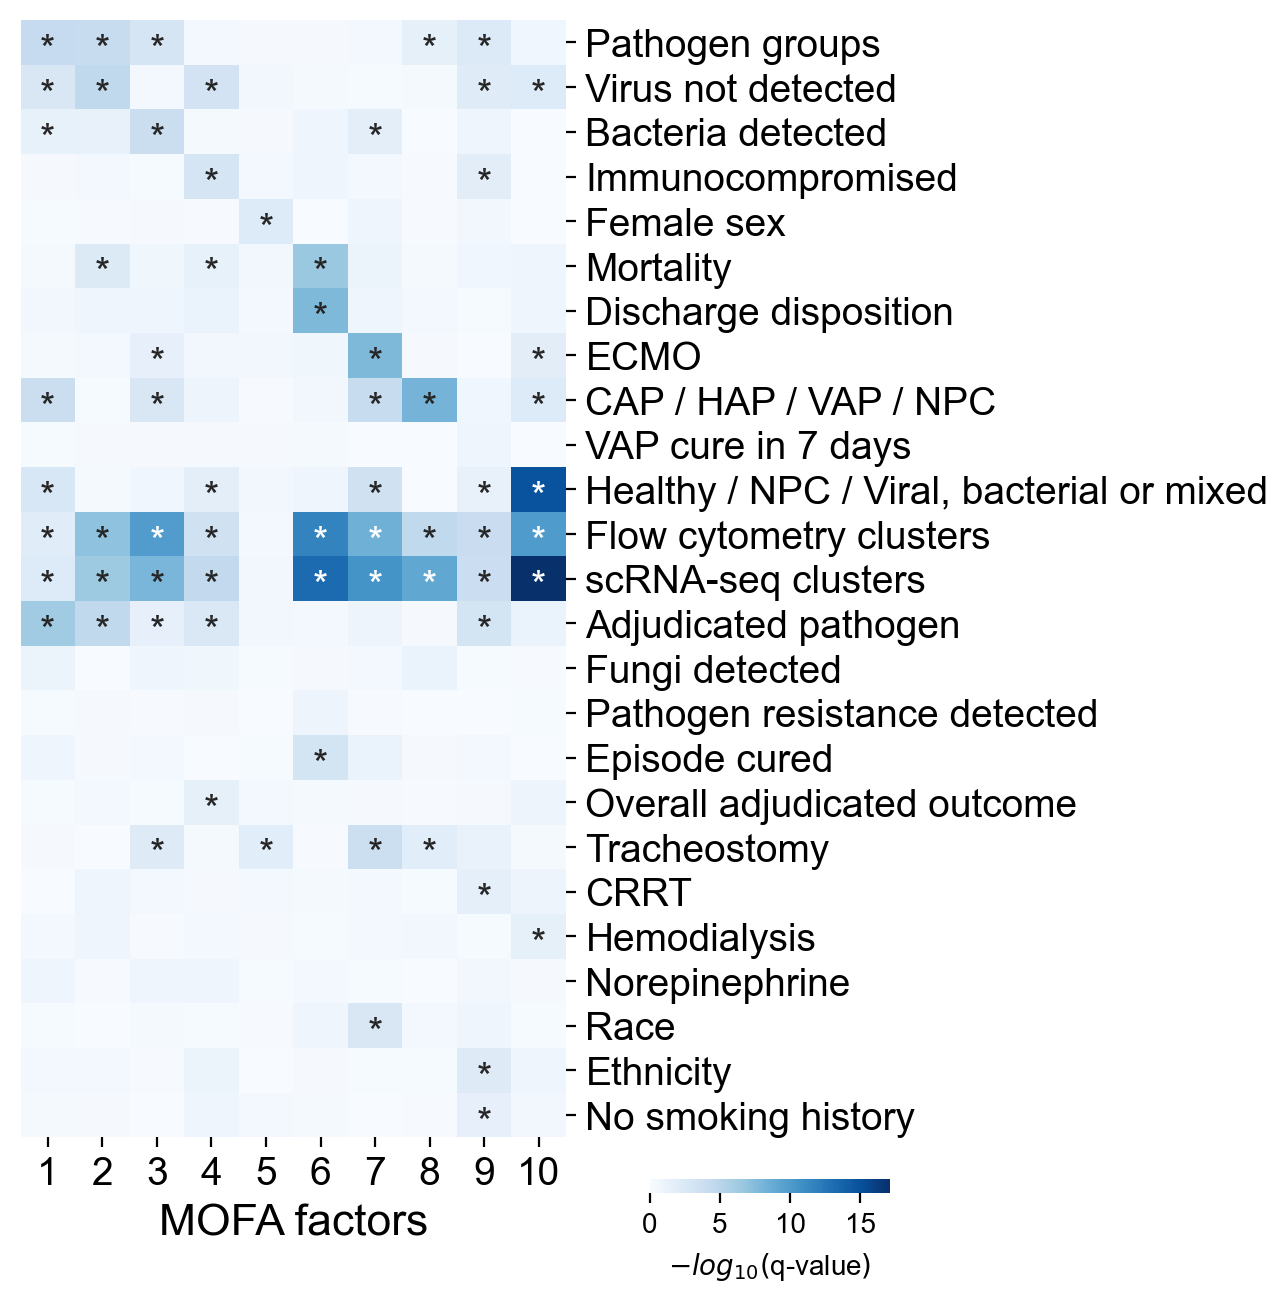

In [22]:
cg = sns.clustermap(
    -np.log10(pc_corrs.loc[:, CAT_ORDER]).T.iloc[:, FACTOR_ORDER],
    method='ward',
    cmap='Blues',
    annot=pc_annot.loc[:, CAT_ORDER].T.iloc[:, FACTOR_ORDER],
    annot_kws=dict(
        size=14
    ),
    col_cluster=False,
    row_cluster=False,
    fmt='s',
    cbar_kws=dict(
        label='$-log_{10}($q-value$)$',
        orientation='horizontal'
    ),
    dendrogram_ratio=0.0001,
    yticklabels=[PRETTY_CAT_NAMES.get(s, s).replace('_', ' ').replace('flag', '').strip() for s in CAT_ORDER],
    figsize=(6, 7)
)
# cg.ax_heatmap.set_title(f'MOFA factors categorical associations', size=16)

cg.ax_heatmap.set_xticklabels(
    [str(x) for x in range(1, 11)],
    fontsize=14,
    rotation=0,
    ha='center'
)
cg.ax_heatmap.set_xlabel(f'MOFA factors', size=16)
# trans = mpl.transforms.Affine2D().translate(-8, 0)
# for t in cg.ax_heatmap.get_xticklabels():
#     t.set_transform(t.get_transform() + trans)

for t in cg.ax_heatmap.get_yticklabels():
    t.set_text(t.get_text().replace('_', ' '))
    t.set_size(14)

for t in cg.ax_heatmap.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))

cg.figure.subplots_adjust(bottom=0.18, right=0.48)
cg.ax_cbar.set_position((0.55, 0.14, 0.2, 0.01))
cg.ax_cbar.set_xticks([0, 5, 10, 15])
cg.figure.savefig('00_plots/03a_cat_assoc.pdf')

In [23]:
assoc_df = -np.log10(pc_corrs.loc[:, CAT_ORDER]).T.iloc[:, FACTOR_ORDER]
assoc_df.index = [PRETTY_CAT_NAMES.get(s, s).replace('_', ' ').replace('flag', '').strip() for s in CAT_ORDER]
assoc_df.to_csv('explore_mofa/03_cat_assoc.csv')

### Save to supplemental table

In [24]:
PRETTY_CAT_NAMES_TXT = {
    'Episode_etiology': 'Adjudicated pathogen',
    'Pathogen_virus_detected': 'Virus detected',
    'Pathogen_bacteria_detected': 'Bacteria detected',
    'Global_cause_failure': 'Overall adjudicated outcome',
    'VAP_is_cured_d7': 'VAP cure in 7 days',
    'Pathogen_fungi_detected': 'Fungi detected',
    'Episode_is_cured': 'Episode cured',
    'Binary_outcome': 'Mortality',
    'Sex': 'Sex',
    'Smoking_status': 'Smoking history',
    'Episode_category': 'CAP / HAP/ VAP / NPC',
    'Healthy_vs_NPC_vs_Pathogen': 'Healthy / NPC / Viral, bacterial or mixed',
    'Flow_clusters': 'Flow cytometry clusters',
    'ScRNAseq_clusters': 'scRNA-seq clusters'
}

In [25]:
PRETTY_CAT_VALUES = {
    'Healthy_vs_NPC_vs_Pathogen': {
        'Pathogen': 'Viral, bacterial or mixed'
    },
    'Binary_outcome': {
        0: 'Survived',
        1: 'Died'
    },
    'Episode_etiology': {
        'Culture-negative': 'Pathogen-negative'
    },
    'Pathogen_groupds': {
        'Gram-*': 'Other Gram–',
        'Gram-*; Gram+': 'Other Gram–; Gram+'
    }
}

In [26]:
category_numbers = []
for column in categorical_covariates.columns:
    unique_vals = list(model_data[column].unique())
    na_value = na_values[column]
    if not isinstance(na_value, list):
        na_value = [na_value]
    any_na = False
    for _na in na_value:
        if _na in unique_vals:
            unique_vals.remove(_na)
            any_na = True

    for val in sorted(unique_vals):
        count = model_data[column].eq(val).sum()
        if len(set(unique_vals) - {'0', '1'}) == 0:
            val = bool(int(val))
        category_numbers.append(dict(
            category=PRETTY_CAT_NAMES_TXT.get(column, column).replace('_', ' ').replace('flag', '').strip(),
            value=PRETTY_CAT_VALUES.get(column, {}).get(val, val),
            count=count
        ))
    if any_na:
        count = model_data[column].isin(na_value).sum()
        category_numbers.append(dict(
            category=PRETTY_CAT_NAMES_TXT.get(column, column).replace('_', ' ').replace('flag', '').strip(),
            value='NA',
            count=count
        ))
category_numbers = pd.DataFrame(category_numbers).rename(columns={
    'category': 'Variable',
    'value': 'Value',
    'count': 'Number of samples'
})

In [28]:
category_numbers.to_csv('00_plots/03_mofa_cat_numbers.csv')

In [29]:
category_numbers

,Variable,Value,Number of samples
0,Mortality,Survived,112
1,Mortality,Died,148
2,Mortality,NA,9
3,CRRT,False,226
4,CRRT,True,34
...,...,...,...
114,"Healthy / NPC / Viral, bacterial or mixed","Viral, bacterial or mixed",149
115,"Healthy / NPC / Viral, bacterial or mixed",NA,86
116,VAP cure in 7 days,False,22
117,VAP cure in 7 days,True,19


In [28]:
num_features_without_tech = numerical_covariates.columns.copy()
num_features_without_tech = num_features_without_tech[~num_features_without_tech.isin([
    'sequencing_depth', 'sequencing_saturation', 'frac_reads_in_cells', 'viability'
])]

In [29]:
pc_corrs, pc_corr_pvals = fi.test_correlation(
    model_data[factors],
    model_data[num_features_without_tech],
    na_values=dict(
        sequencing_depth=-1,
        sequencing_saturation=-1,
        frac_reads_in_cells=-1,
        viability=-1,
    )
)

In [30]:
PRETTY_NUM_NAMES = {
    'BAL_pct_lymphocytes': 'BAL lymphocytes (%)',
    'Minute_Ventilation': 'Minute ventilation',
    'BAL_pct_neutrophils': 'BAL neutrophils (%)',
    'cumulative_icu_steroid_dose_until_today': 'ICU steroid dose to date',
    'PaO2FIO2_ratio': r'P$_{\mathrm{a}}$O$_2$/F$_{\mathrm{i}}$O$_2$',
    'days_on_ventilator': 'Days on ventilator',
    'D_dimer_ff': 'D-dimer',
    'days_of_icu_abx_until_today': 'ICU antibiotic days to date',
    'ABG_PaCO2': r'P$_{\mathrm{a}}$CO$_2$',
    'GSC_score': 'GCS score'
}
def pretty_num(name: str) -> str:
    name = PRETTY_NUM_NAMES.get(name, name)
    if '$' in name:
        idx = name.index('$')
        name = name[:idx].replace('_', ' ') + name[idx:]
    else:
        name = name.replace('_', ' ')
    return name

Number of exact 0: 0


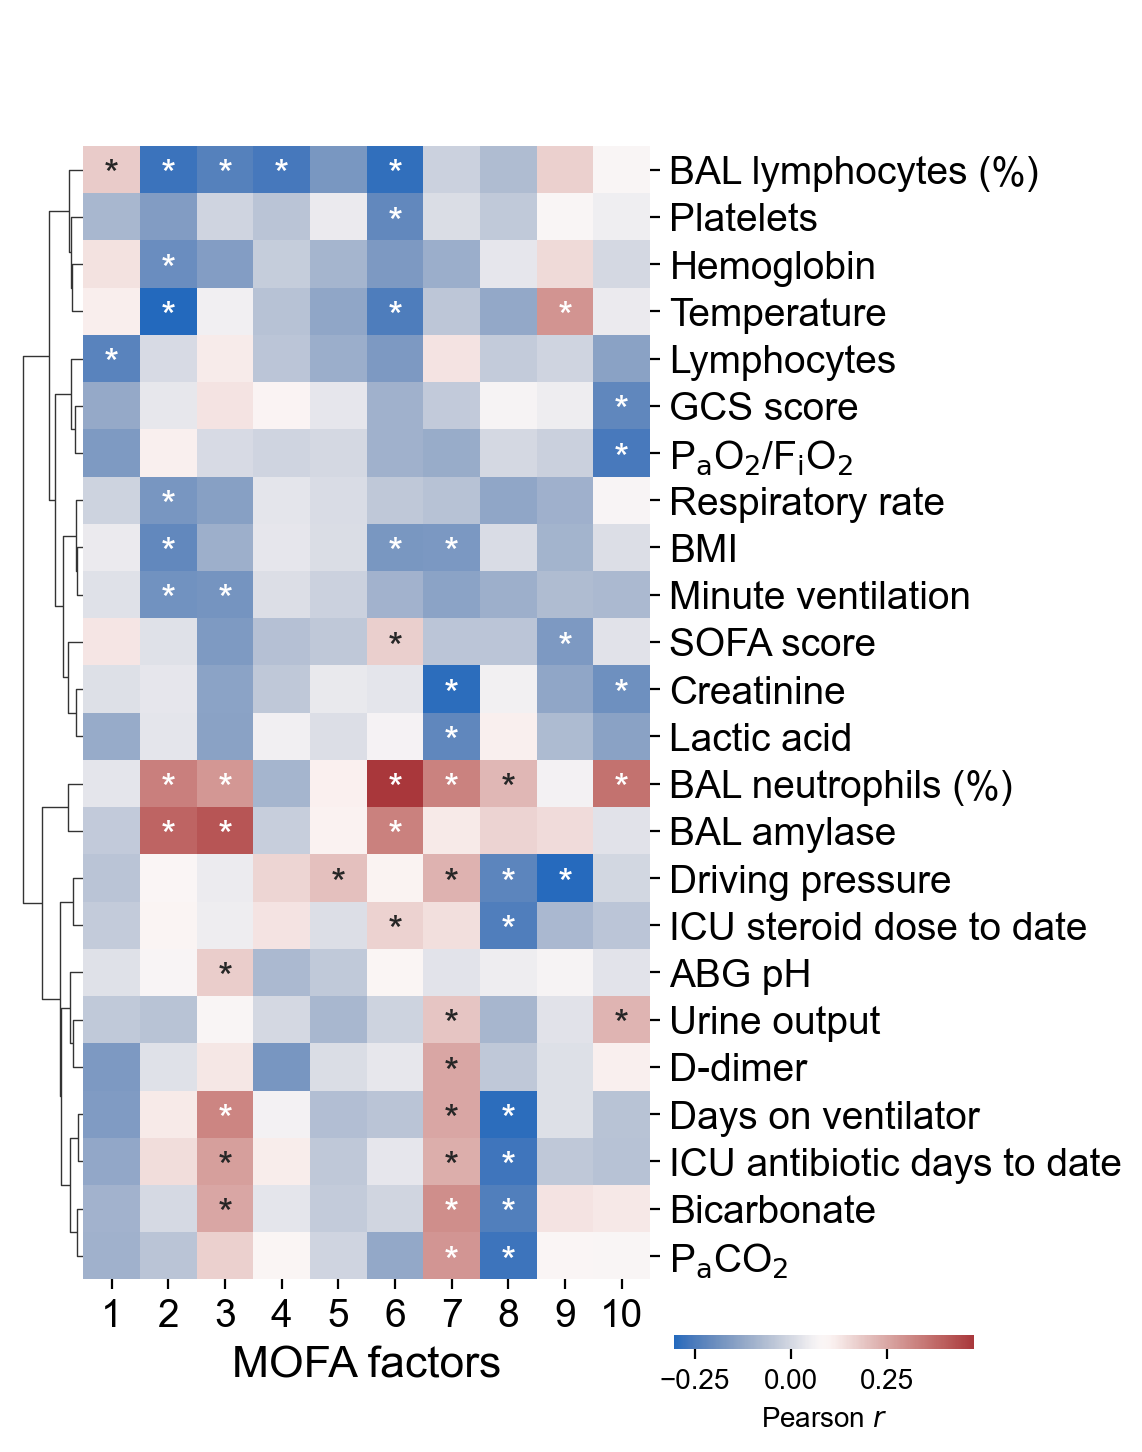

In [31]:
idx = pc_corr_pvals == 0
print(f'Number of exact 0: {idx.sum().sum()}')
min_pval = pc_corr_pvals.to_numpy()[~idx].min()
pc_corr_pvals[idx] = min_pval * 0.1
pc_annot = pd.DataFrame(index=pc_corr_pvals.index, columns=pc_corr_pvals.columns)
pc_annot[pc_corr_pvals.lt(0.05) & pc_corrs.abs().gt(0.15)] = '*'
pc_annot[pc_annot != '*'] = ''
to_keep = pc_corr_pvals.lt(0.05).sum().gt(0)
cg = sns.clustermap(
    pc_corrs.loc[:, to_keep].T.iloc[:, FACTOR_ORDER],
    method='ward',
    cmap='vlag',
    annot=pc_annot.loc[:, to_keep].T.iloc[:, FACTOR_ORDER],
    annot_kws=dict(
        size=14
    ),
    col_cluster=False,
    fmt='s',
    cbar_kws=dict(
        label='Pearson $r$',
        orientation='horizontal'
    ),
    dendrogram_ratio=0.1,
    yticklabels=[pretty_num(s) for s in pc_annot.columns[to_keep]],
    figsize=(6, 7)
)
# cg.ax_heatmap.set_title(f'MOFA factors categorical associations', size=16)


cg.ax_heatmap.set_xticklabels(
    [str(x) for x in range(1, 11)],
    fontsize=14,
    rotation=0,
    ha='center'
)
cg.ax_heatmap.set_xlabel(f'MOFA factors', size=16)
# trans = mpl.transforms.Affine2D().translate(-8, 0)
# for t in cg.ax_heatmap.get_xticklabels():
#     t.set_transform(t.get_transform() + trans)

for t in cg.ax_heatmap.get_yticklabels():
    t.set_text(t.get_text().replace('_', ' '))
    t.set_size(14)

for t in cg.ax_heatmap.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.15))

cg.figure.subplots_adjust(top=1.05, bottom=0.15, right=0.55)
cg.ax_cbar.set_position((0.57, 0.10, 0.25, 0.01))
cg.figure.savefig('00_plots/03b_num_assoc.pdf')

Export all covariates to browser, not just significant

In [32]:
assoc_df = pc_corrs.T.iloc[:, FACTOR_ORDER]
assoc_df.index = [pretty_num(s) for s in pc_annot.columns]
assoc_df.to_csv('explore_mofa/03_num_assoc_corr.csv')

In [33]:
assoc_df = pc_corr_pvals.T.iloc[:, FACTOR_ORDER]
assoc_df.index = [pretty_num(s) for s in pc_annot.columns]
assoc_df.to_csv('explore_mofa/03_num_assoc_pval.csv')

In [34]:
model_data.to_csv('explore_mofa/03_model_data.csv')

## Box plots

/tmp/ipykernel_187214/60787730.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df[c] = pc_df[c].cat.remove_unused_categories()
/tmp/ipykernel_187214/60787730.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df.Binary_outcome = pc_df.Binary_outcome.cat.rename_categories({
/tmp/ipykernel_187214/60787730.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn

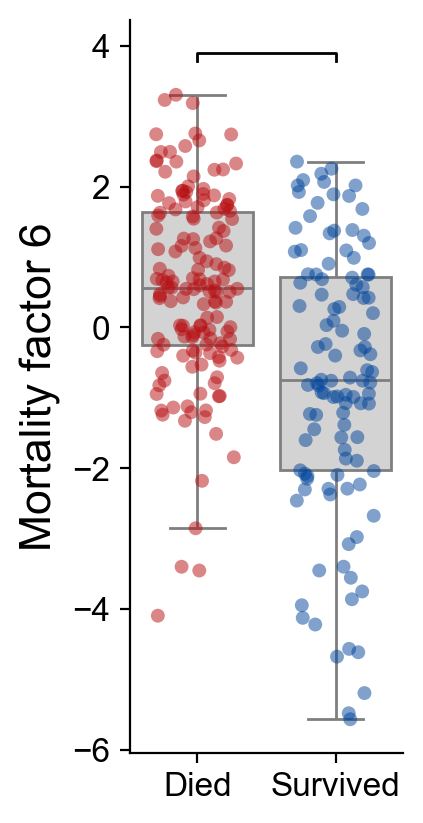

In [35]:
pc_df, pc, cat, na_values = (
    model_data,
    'factor_1_score',
    'Binary_outcome',
    na_values)

# pc_df = pc_df.loc[pc_df.Pathogen_groups_detailed.ne('discard')].copy()
pc_df = pc_df.loc[pc_df[cat].ne(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
pc_df.Binary_outcome = pc_df.Binary_outcome.cat.rename_categories({
    '0': 'Survived',
    '1': 'Died'
})

fig, ax = plt.subplots(figsize=(2, 4), constrained_layout=True)
stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=[HIGHLIGHT_COLOR,'#00459b'],
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 30 # px
labels = [x.get_text() for x in ax.get_xticklabels()]
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap / 4
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    # txt = ax.text((x1+x2)*.5, y+1.1*h, p, ha='center', va='bottom', color=col, size=14)
    y += y_offset

# ax.patches[0].set_edgecolor(HIGHLIGHT_COLOR)
# for l in ax.lines[:5]:
#     l.set_color(HIGHLIGHT_COLOR)
# ax.patches[0].set_linestyle(HIGHLIGHT_COLOR)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=12)
ax.set_xlabel('', size=14, x=0.3)
ax.set_ylabel('Mortality factor 6', size=16)
# ax.get_xticklabels()[0].set_transform(
#     ax.get_xticklabels()[0].get_transform() + mpl.transforms.Affine2D().translate(-8, 0)
# )
fig.savefig('00_plots/03_boxplot_binary_outcome.pdf')

/tmp/ipykernel_187214/844361565.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df[c] = pc_df[c].cat.remove_unused_categories()
/tmp/ipykernel_187214/844361565.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df.VAP_is_cured_d7 = pc_df.VAP_is_cured_d7.cat.rename_categories({
/tmp/ipykernel_187214/844361565.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


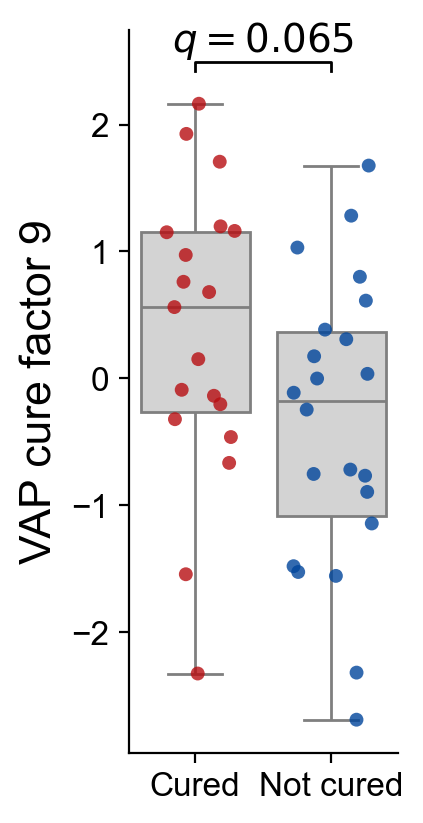

In [36]:
pc_df, pc, cat, na_values = (
    model_data,
    'factor_2_score',
    'VAP_is_cured_d7',
    na_values)

# pc_df = pc_df.loc[pc_df.Pathogen_groups_detailed.ne('discard')].copy()
pc_df = pc_df.loc[pc_df[cat].ne(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
pc_df.VAP_is_cured_d7 = pc_df.VAP_is_cured_d7.cat.rename_categories({
    '0': 'Not cured',
    '1': 'Cured'
})

fig, ax = plt.subplots(figsize=(2, 4), constrained_layout=True)
stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]
stats_results_sign = stats_results

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=[HIGHLIGHT_COLOR,'#00459b'],
    alpha=0.8,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 30 # px
labels = [x.get_text() for x in ax.get_xticklabels()]
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap / 4
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    txt = ax.text((x1+x2)*.5, y+1.1*h, p, ha='center', va='bottom', color=col, size=14)
    y += y_offset

# ax.patches[0].set_edgecolor(HIGHLIGHT_COLOR)
# for l in ax.lines[:5]:
#     l.set_color(HIGHLIGHT_COLOR)
# ax.patches[0].set_linestyle(HIGHLIGHT_COLOR)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=12)
ax.set_xlabel('', size=14, x=0.3)
ax.set_ylabel('VAP cure factor 9', size=16)
# ax.get_xticklabels()[0].set_transform(
#     ax.get_xticklabels()[0].get_transform() + mpl.transforms.Affine2D().translate(-15, 0)
# )
fig.savefig('00_plots/03_boxplot_vap_cured.pdf')

/tmp/ipykernel_187214/3087192961.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df[c] = pc_df[c].cat.remove_unused_categories()
/tmp/ipykernel_187214/3087192961.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df.Episode_category = pc_df.Episode_category.cat.reorder_categories([
/tmp/ipykernel_187214/3087192961.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same ef

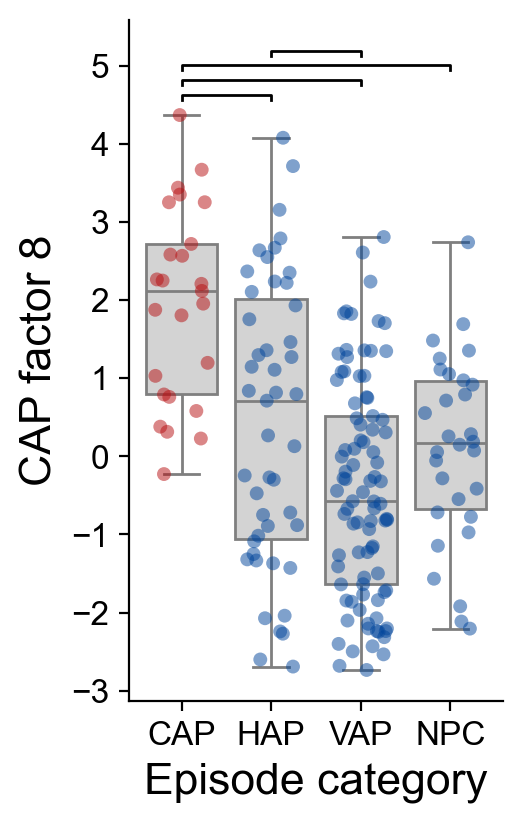

In [37]:
pc_df, pc, cat, na_values = (
    model_data,
    'factor_3_score',
    'Episode_category',
    na_values)

# pc_df = pc_df.loc[pc_df.Pathogen_groups_detailed.ne('discard')].copy()
pc_df = pc_df.loc[pc_df[cat].ne(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
pc_df.Episode_category = pc_df.Episode_category.cat.reorder_categories([
    'CAP', 'HAP', 'VAP', 'NPC'
])

fig, ax = plt.subplots(figsize=(2.5, 4), constrained_layout=True)
stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=[HIGHLIGHT_COLOR, '#00459b', '#00459b', '#00459b'],
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 5 # px
labels = [x.get_text() for x in ax.get_xticklabels()]
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    # txt = ax.text((x1+x2)*.5, y+1.1*h, p, ha='center', va='bottom', color=col, size=14)
    y += y_offset

# ax.patches[0].set_edgecolor(HIGHLIGHT_COLOR)
# for l in ax.lines[:5]:
#     l.set_color(HIGHLIGHT_COLOR)
# ax.patches[0].set_linestyle(HIGHLIGHT_COLOR)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=12)
ax.set_xlabel('Episode category', size=16, x=0.5)
ax.set_ylabel('CAP factor 8', size=16)
fig.savefig('00_plots/03_boxplot_cap.pdf')

/tmp/ipykernel_187214/404598777.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


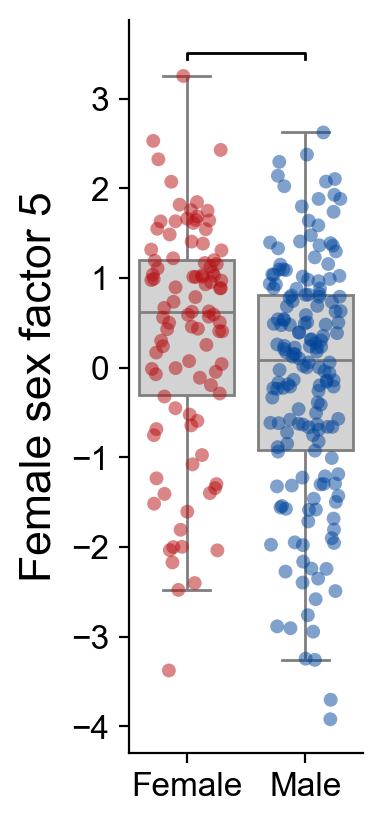

In [38]:
pc_df, pc, cat, na_values = (
    model_data,
    'factor_4_score',
    'Sex',
    na_values)

# pc_df = pc_df.loc[pc_df.Pathogen_groups_detailed.ne('discard')].copy()
pc_df = pc_df.loc[pc_df[cat].ne(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(1.8, 4), constrained_layout=True)
stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=[HIGHLIGHT_COLOR,'#00459b'],
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 5 # px
labels = [x.get_text() for x in ax.get_xticklabels()]
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    # txt = ax.text((x1+x2)*.5, y+1.1*h, p, ha='center', va='bottom', color=col, size=14)
    y += y_offset

# ax.patches[0].set_edgecolor(HIGHLIGHT_COLOR)
# for l in ax.lines[:5]:
#     l.set_color(HIGHLIGHT_COLOR)
# ax.patches[0].set_linestyle(HIGHLIGHT_COLOR)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=12)
ax.set_xlabel('', size=16)
ax.set_ylabel('Female sex factor 5', size=16)
fig.savefig('00_plots/03_boxplot_sex.pdf')

/tmp/ipykernel_187214/1329028808.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df[c] = pc_df[c].cat.remove_unused_categories()
/tmp/ipykernel_187214/1329028808.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df.ECMO_flag = pc_df.ECMO_flag.cat.reorder_categories(['1', '0']).cat.rename_categories({
/tmp/ipykernel_187214/1329028808.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fa

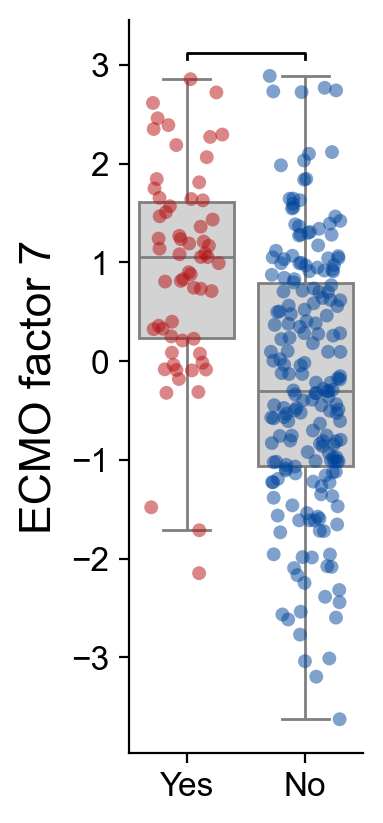

In [39]:
pc_df, pc, cat, na_values = (
    model_data,
    'factor_5_score',
    'ECMO_flag',
    na_values)

# pc_df = pc_df.loc[pc_df.Pathogen_groups_detailed.ne('discard')].copy()
pc_df = pc_df.loc[pc_df[cat].ne(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
pc_df.ECMO_flag = pc_df.ECMO_flag.cat.reorder_categories(['1', '0']).cat.rename_categories({
    '0': 'No',
    '1': 'Yes'
})

fig, ax = plt.subplots(figsize=(1.8, 4), constrained_layout=True)
stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=[HIGHLIGHT_COLOR,'#00459b'],
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 5 # px
labels = [x.get_text() for x in ax.get_xticklabels()]
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    # txt = ax.text((x1+x2)*.5, y+1.1*h, p, ha='center', va='bottom', color=col, size=14)
    y += y_offset

# ax.patches[0].set_edgecolor(HIGHLIGHT_COLOR)
# for l in ax.lines[:5]:
#     l.set_color(HIGHLIGHT_COLOR)
# ax.patches[0].set_linestyle(HIGHLIGHT_COLOR)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=12)
ax.set_xlabel('', size=16)
ax.set_ylabel('ECMO factor 7', size=16)
fig.savefig('00_plots/03_boxplot_ecmo.pdf')

/tmp/ipykernel_187214/395548461.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df[c] = pc_df[c].cat.remove_unused_categories()
/tmp/ipykernel_187214/395548461.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df.Immunocompromised_flag = pc_df.Immunocompromised_flag.cat.reorder_categories(['1', '0']).cat.rename_categories({
/tmp/ipykernel_187214/395548461.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `

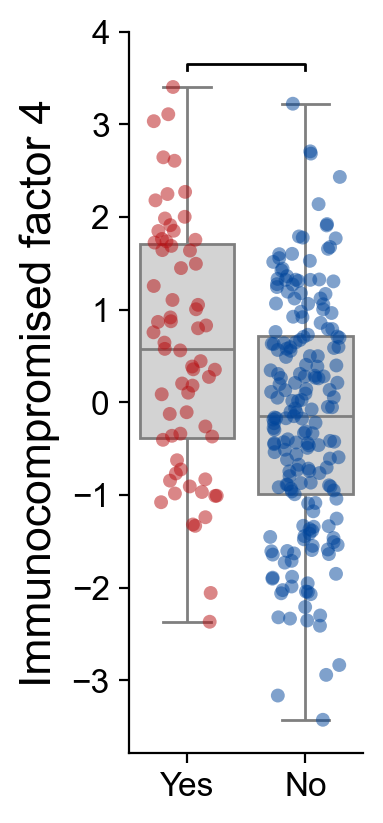

In [40]:
pc_df, pc, cat, na_values = (
    model_data,
    'factor_6_score',
    'Immunocompromised_flag',
    na_values)

# pc_df = pc_df.loc[pc_df.Pathogen_groups_detailed.ne('discard')].copy()
pc_df = pc_df.loc[pc_df[cat].ne(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
pc_df.Immunocompromised_flag = pc_df.Immunocompromised_flag.cat.reorder_categories(['1', '0']).cat.rename_categories({
    '0': 'No',
    '1': 'Yes'
})

fig, ax = plt.subplots(figsize=(1.8, 4), constrained_layout=True)
stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=[HIGHLIGHT_COLOR,'#00459b'],
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 5 # px
labels = [x.get_text() for x in ax.get_xticklabels()]
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    # txt = ax.text((x1+x2)*.5, y+1.1*h, p, ha='center', va='bottom', color=col, size=14)
    y += y_offset

# ax.patches[0].set_edgecolor(HIGHLIGHT_COLOR)
# for l in ax.lines[:5]:
#     l.set_color(HIGHLIGHT_COLOR)
# ax.patches[0].set_linestyle(HIGHLIGHT_COLOR)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=12)
ax.set_xlabel('', size=14, x=0.3)
ax.set_ylabel('Immunocompromised factor 4', size=16)
fig.savefig('00_plots/03_boxplot_immunocomp.pdf')

/tmp/ipykernel_187214/1472190144.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df[c] = pc_df[c].cat.remove_unused_categories()


/tmp/ipykernel_187214/1472190144.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


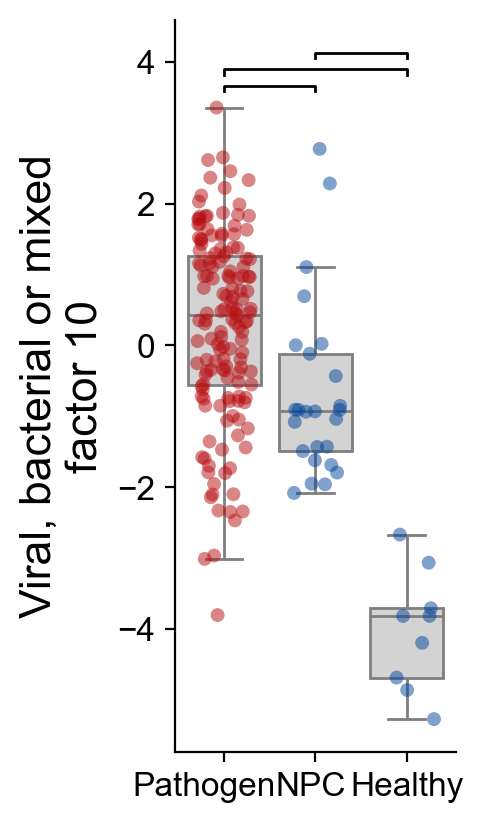

In [41]:
pc_df, pc, cat, na_values = (
    model_data,
    'factor_8_score',
    'Healthy_vs_NPC_vs_Pathogen',
    na_values)

# pc_df = pc_df.loc[pc_df.Pathogen_groups_detailed.ne('discard')].copy()
pc_df = pc_df.loc[pc_df[cat].ne(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
# pc_df.Immunocompromised_flag = pc_df.Immunocompromised_flag.cat.reorder_categories(['1', '0']).cat.rename_categories({
#     '0': 'No',
#     '1': 'Yes'
# })

fig, ax = plt.subplots(figsize=(2.3, 4), constrained_layout=True)
stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=[HIGHLIGHT_COLOR,'#00459b', '#00459b'],
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 5 # px
labels = [x.get_text() for x in ax.get_xticklabels()]
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    # txt = ax.text((x1+x2)*.5, y+1.1*h, p, ha='center', va='bottom', color=col, size=14)
    y += y_offset

# ax.patches[0].set_edgecolor(HIGHLIGHT_COLOR)
# for l in ax.lines[:5]:
#     l.set_color(HIGHLIGHT_COLOR)
# ax.patches[0].set_linestyle(HIGHLIGHT_COLOR)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=12)
ax.set_xlabel('', size=16, x=0.4)
ax.set_ylabel('Viral, bacterial or mixed\nfactor 10', size=16)
ax.get_xticklabels()[0].set_transform(
    ax.get_xticklabels()[0].get_transform() + mpl.transforms.Affine2D().translate(-20, 0)
)
ax.get_xticklabels()[1].set_transform(
    ax.get_xticklabels()[1].get_transform() + mpl.transforms.Affine2D().translate(-5, 0)
)
fig.savefig('00_plots/03_boxplot_pathogen.pdf')

Adding pathogen-negative data

In [42]:
sc_labels = pd.read_csv(common_data.SC_LABELS, index_col=0)

In [43]:
sc_labels.is_culture_negative_pneumonia.sum()

32

In [44]:
path_neg_samples = sc_labels.bal_barcode[sc_labels.is_culture_negative_pneumonia.fillna(False)]
len(path_neg_samples)

32

In [45]:
sc_labels.perturbation_groups_2[sc_labels.bal_barcode.isin(path_neg_samples)].eq('discard').all()

True

/tmp/ipykernel_187214/2674142565.py:26: FutureWarning: The `inplace` parameter in pandas.Categorical.add_categories is deprecated and will be removed in a future version. Removing unused categories will always return a new Categorical object.
  pc_df.Pathogen_groups.cat.add_categories('Pathogen-negative', inplace=True)
/tmp/ipykernel_187214/2674142565.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_187214/2674142565.py:60: UserWarning: The palette list has more values (11) than needed (10), which may not be intended.
  sns.stripplot(
/tmp/ipykernel_187214/2674142565.py:112: FutureWarning: The `inplace` parameter in pandas.Categorical.add_categories is deprecated and will be removed in a future version. Removing unused categories will always return a new Categorical object.
  pc_df.Pathogen_groups.cat.add_categories

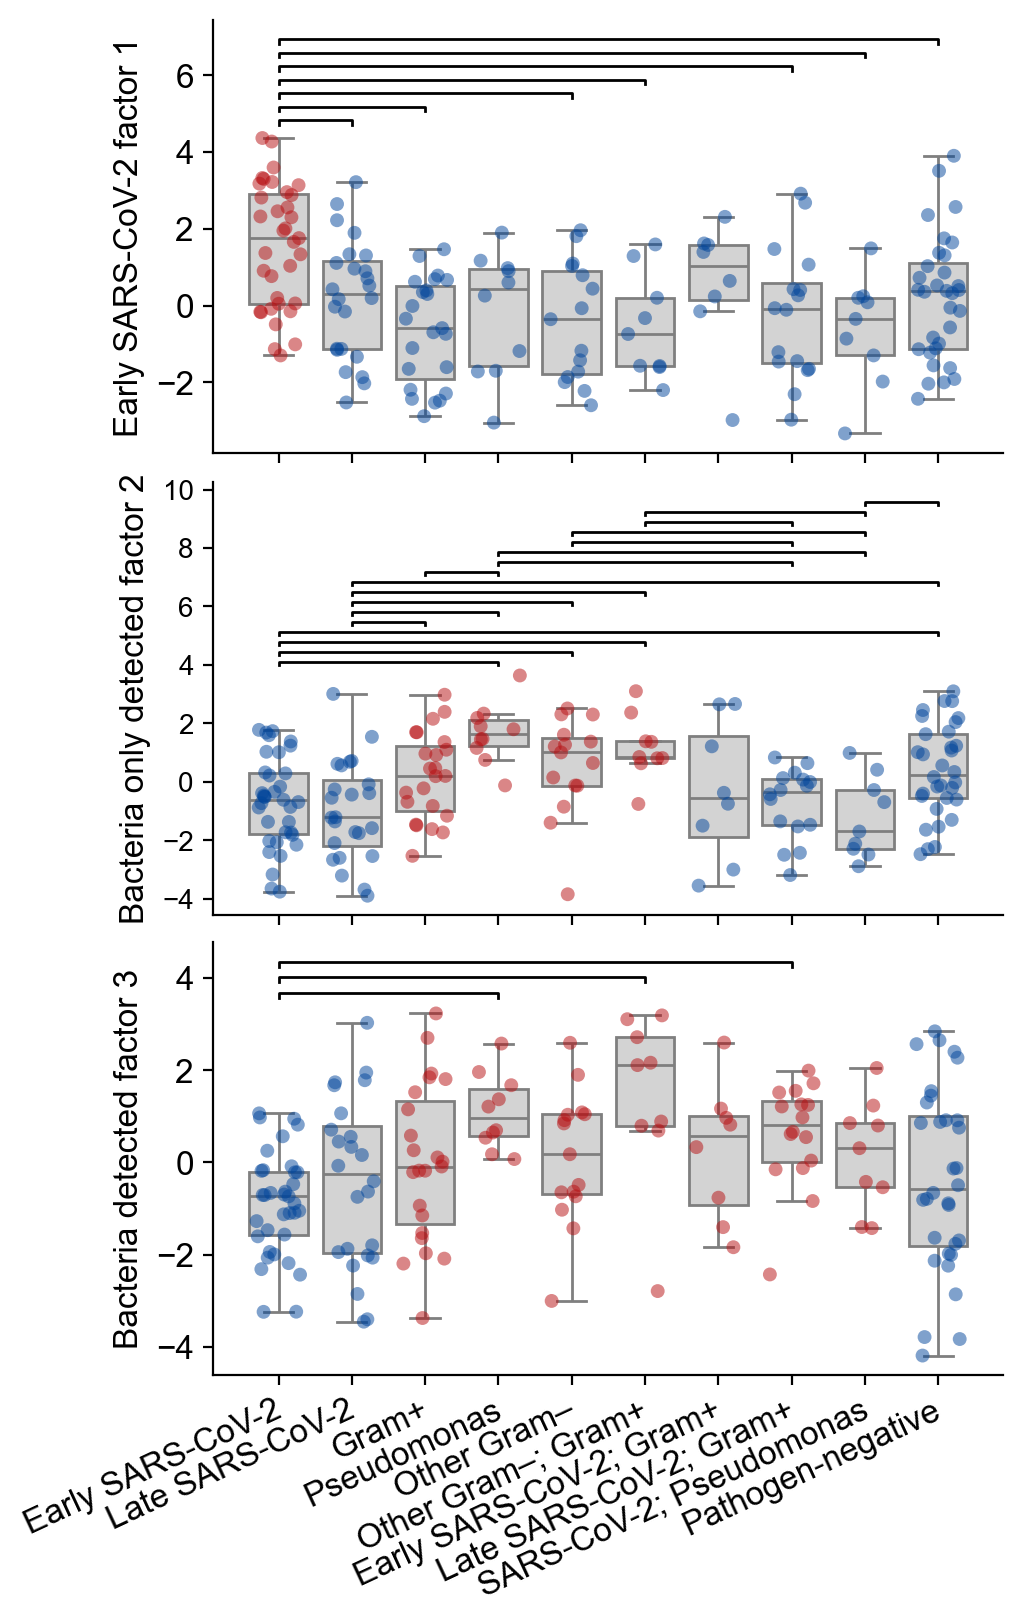

In [53]:
fig, axes = plt.subplots(figsize=(5, 8), constrained_layout=True, nrows=3, sharex=True)

PATH_ORDER = [
    'Early SARS-CoV-2',
    'Late SARS-CoV-2',
    'Gram+',
    'Pseudomonas',
    'Gram-*',
    'Gram-*; Gram+',
    'Early SARS-CoV-2; Gram+',
    'Late SARS-CoV-2; Gram+',
    'Pseudomonas; SARS-CoV-2',
    'Pathogen-negative',
]

# ================== FACTOR 7
ax = axes[0]

pc_df, pc, cat, na_values = (
    model_data,
    'factor_7_score',
    'Pathogen_groups',
    na_values)

pc_df = pc_df.copy()
pc_df.Pathogen_groups.cat.add_categories('Pathogen-negative', inplace=True)
pc_df.loc[path_neg_samples, 'Pathogen_groups'] = 'Pathogen-negative'
pc_df = pc_df.loc[pc_df.Pathogen_groups.ne('discard')].copy()
pc_df = pc_df.loc[~pc_df[cat].isin(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
pc_df.Pathogen_groups = pc_df.Pathogen_groups.cat.reorder_categories(PATH_ORDER)

stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=[HIGHLIGHT_COLOR] + ['#00459b'] * 10,
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 5 # px
labels = PATH_ORDER
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    y += y_offset

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=12)
ax.set_xlabel('')
ax.set_ylabel('Early SARS-CoV-2 factor 1', size=12)

# ================== FACTOR 9
ax = axes[2]

pc_df, pc, cat, na_values = (
    model_data,
    'factor_9_score',
    'Pathogen_groups',
    na_values)

pc_df = pc_df.copy()
pc_df.Pathogen_groups.cat.add_categories('Pathogen-negative', inplace=True)
pc_df.loc[path_neg_samples, 'Pathogen_groups'] = 'Pathogen-negative'
pc_df = pc_df.loc[pc_df.Pathogen_groups.ne('discard')].copy()
pc_df = pc_df.loc[~pc_df[cat].isin(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
pc_df.Pathogen_groups = pc_df.Pathogen_groups.cat.reorder_categories(PATH_ORDER)

stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=['#00459b'] * 2 + [HIGHLIGHT_COLOR] * 7 + ['#00459b'],
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 5 # px
labels = PATH_ORDER
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    y += y_offset

ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=12)
ax.set_xlabel('')
ax.set_ylabel('Bacteria detected factor 3', size=12)

# ================== FACTOR 10
ax = axes[1]

pc_df, pc, cat, na_values = (
    model_data,
    'factor_10_score',
    'Pathogen_groups',
    na_values)

pc_df = pc_df.copy()
pc_df.Pathogen_groups.cat.add_categories('Pathogen-negative', inplace=True)
pc_df.loc[path_neg_samples, 'Pathogen_groups'] = 'Pathogen-negative'
pc_df = pc_df.loc[pc_df.Pathogen_groups.ne('discard')].copy()
pc_df = pc_df.loc[~pc_df[cat].isin(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
pc_df.Pathogen_groups = pc_df.Pathogen_groups.cat.reorder_categories(PATH_ORDER)

stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=['#00459b'] * 2 + [HIGHLIGHT_COLOR] * 4 + ['#00459b'] * 4,
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 5 # px
labels = PATH_ORDER
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    y += y_offset

ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('', size=16)
ax.set_ylabel('Bacteria only detected factor 2', size=12)

ax = axes[2]
ax.tick_params(labelsize=12)
ax.set_xticklabels([
    'Early SARS-CoV-2',
    'Late SARS-CoV-2',
    'Gram+',
    'Pseudomonas',
    'Other Gram–',
    'Other Gram–; Gram+',
    'Early SARS-CoV-2; Gram+',
    'Late SARS-CoV-2; Gram+',
    'SARS-CoV-2; Pseudomonas',
    'Pathogen-negative',
])

trans = mpl.transforms.Affine2D().translate(8, 0)
for t in ax.get_xticklabels():
    t.set_rotation(25)
    t.set_size(12)
    t.set_horizontalalignment("right")
    t.set_transform(t.get_transform() + trans)

# fig.subplots_adjust(right=0.9, top=0.99, left=0.22, bottom=0.2)
fig.savefig('00_plots/03_boxplot_factor_7_9_10.pdf')

/tmp/ipykernel_187214/2219667495.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df[c] = pc_df[c].cat.remove_unused_categories()
/tmp/ipykernel_187214/2219667495.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df[cat] = pc_df[cat].cat.reorder_categories(sorted(pc_df[cat].cat.categories))
/tmp/ipykernel_187214/2219667495.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for th

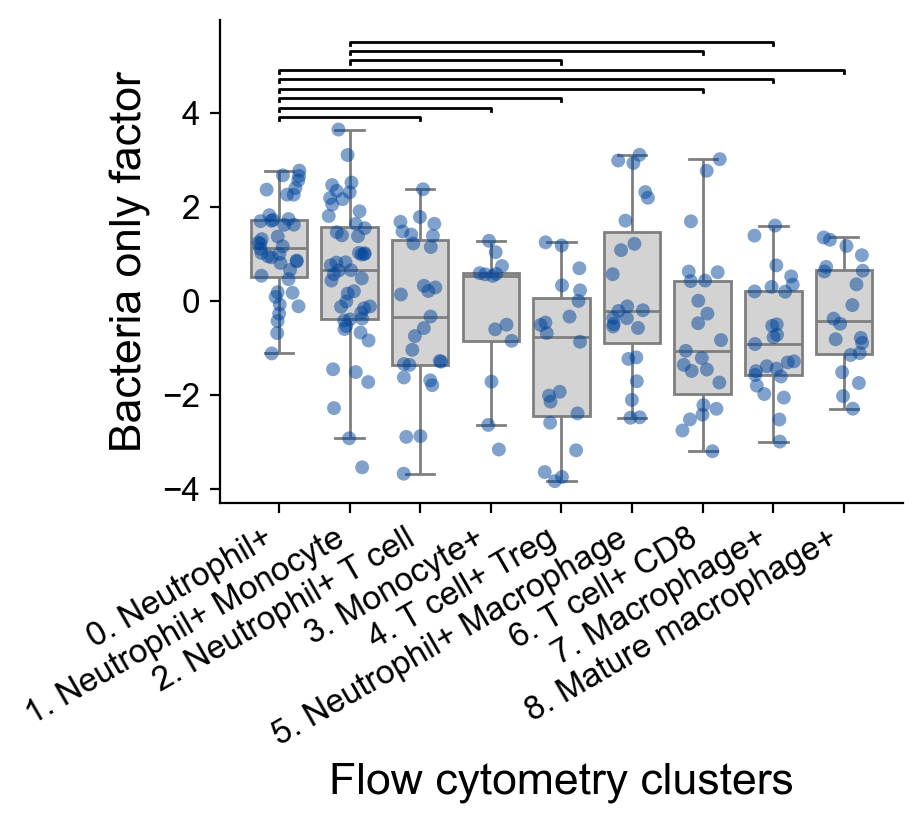

In [47]:
pc_df, pc, cat, na_values = (
    model_data,
    'factor_10_score',
    'Flow_clusters',
    na_values)

# pc_df = pc_df.loc[pc_df.Pathogen_groups_detailed.ne('discard')].copy()
pc_df = pc_df.loc[pc_df[cat].ne(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
pc_df[cat] = pc_df[cat].cat.reorder_categories(sorted(pc_df[cat].cat.categories))
# pc_df.Immunocompromised_flag = pc_df.Immunocompromised_flag.cat.reorder_categories(['1', '0']).cat.rename_categories({
#     '0': 'No',
#     '1': 'Yes'
# })

fig, ax = plt.subplots(figsize=(4.5, 4), constrained_layout=True)
stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=['#00459b'],
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 5 # px
labels = [x.get_text() for x in ax.get_xticklabels()]
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    y += y_offset

ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(range(9), labels=[
    '0. Neutrophil+',
    '1. Neutrophil+ Monocyte',
    '2. Neutrophil+ T cell',
    '3. Monocyte+',
    '4. T cell+ Treg',
    '5. Neutrophil+ Macrophage',
    '6. T cell+ CD8',
    '7. Macrophage+',
    '8. Mature macrophage+',
], ha='right', rotation=30)
ax.tick_params(labelsize=12)
ax.set_xlabel('Flow cytometry clusters', size=16)
ax.set_ylabel('Bacteria only factor', size=16)
fig.savefig('00_plots/03_boxplot_factor_10_flow.pdf')

/tmp/ipykernel_187214/3097022552.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df[c] = pc_df[c].cat.remove_unused_categories()
/tmp/ipykernel_187214/3097022552.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_df[cat] = pc_df[cat].cat.reorder_categories([
/tmp/ipykernel_187214/3097022552.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


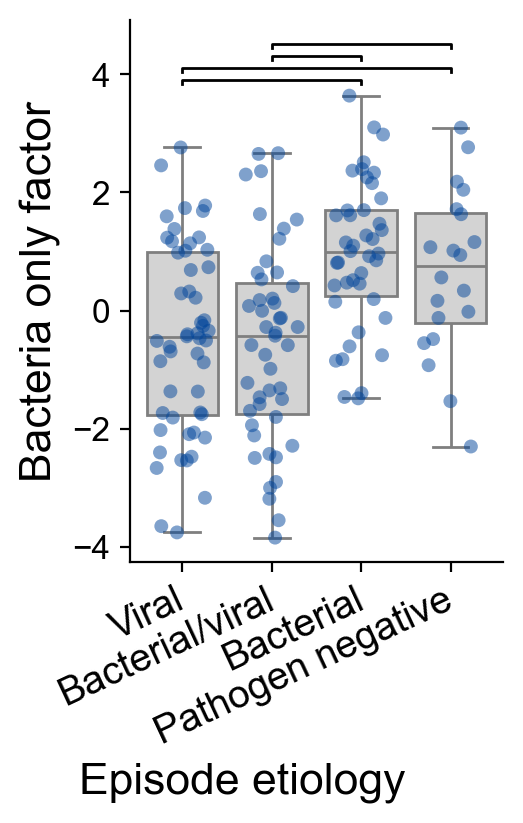

In [48]:
pc_df, pc, cat, na_values = (
    model_data,
    'factor_10_score',
    'Episode_etiology',
    na_values)

# pc_df = pc_df.loc[pc_df.Pathogen_groups_detailed.ne('discard')].copy()
pc_df = pc_df.loc[pc_df[cat].ne(na_values[cat])]
for c in pc_df.columns:
    if pd.api.types.is_categorical_dtype(pc_df[c]):
        pc_df[c] = pc_df[c].cat.remove_unused_categories()
pc_df[cat] = pc_df[cat].cat.reorder_categories([
    'Viral',
    'Bacterial/viral',
    'Bacterial',
    'Culture-negative'
]).cat.rename_categories({
    'Culture-negative': 'Pathogen negative'
})
# pc_df.Immunocompromised_flag = pc_df.Immunocompromised_flag.cat.reorder_categories(['1', '0']).cat.rename_categories({
#     '0': 'No',
#     '1': 'Yes'
# })

fig, ax = plt.subplots(figsize=(2.5, 4), constrained_layout=True)
stats_results = []
na_value = na_values.get(cat)
if not isinstance(na_value, list):
    na_value = [na_value]

for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
    if d1 in na_value or d2 in na_value:
        continue
    days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
    days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results['PC'] = pc
stats_results['covariate'] = cat
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=pc_df, x=cat, y=pc, ax=ax, color='lightgray', showfliers=False)
sns.stripplot(
    data=pc_df,
    x=cat,
    y=pc,
    ax=ax,
    size=5,
    palette=['#00459b'],
    alpha=0.5,
    jitter=0.3
)

start_height = pc_df[pc].max()
incrementer = 5 # px
labels = [x.get_text() for x in ax.get_xticklabels()]
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    y += y_offset

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=12)
ax.set_xlabel('Episode etiology', size=16, x=0.3)
ax.set_ylabel('Bacteria only factor', size=16)

trans = mpl.transforms.Affine2D().translate(8, 0)
for t in ax.get_xticklabels():
    t.set_rotation(25)
    t.set_size(14)
    t.set_horizontalalignment("right")
    t.set_transform(t.get_transform() + trans)

fig.savefig('00_plots/03_boxplot_factor_10_etiology.pdf')

## Precompute all tests for associations

In [49]:
categorical_covariates.columns

Index(['Binary_outcome', 'CRRT_flag', 'Discharge_disposition', 'ECMO_flag',
       'Episode_category', 'Episode_etiology', 'Episode_is_cured', 'Ethnicity',
       'Sex', 'Global_cause_failure', 'Hemodialysis_flag',
       'Immunocompromised_flag', 'Norepinephrine_flag',
       'Pathogen_bacteria_detected', 'Pathogen_fungi_detected',
       'Pathogen_resistance_detected', 'Pathogen_virus_detected', 'Race',
       'Smoking_status', 'Tracheostomy_flag', 'Flow_clusters',
       'ScRNAseq_clusters', 'Pathogen_groups', 'Healthy_vs_NPC_vs_Pathogen',
       'VAP_is_cured_d7'],
      dtype='object')

In [50]:
na_values

{'Binary_outcome': 'NA',
 'CRRT_flag': 'NA',
 'Discharge_disposition': 'NA',
 'ECMO_flag': 'NA',
 'Episode_category': 'NA',
 'Episode_etiology': 'NA',
 'Episode_is_cured': 'NA',
 'Ethnicity': 'Unknown or Not Reported',
 'Sex': 'NA',
 'Global_cause_failure': 'NA',
 'Hemodialysis_flag': 'NA',
 'Immunocompromised_flag': 'NA',
 'Norepinephrine_flag': 'NA',
 'Pathogen_bacteria_detected': 'NA',
 'Pathogen_fungi_detected': 'NA',
 'Pathogen_resistance_detected': 'NA',
 'Pathogen_virus_detected': 'NA',
 'Race': 'Unknown or Not Reported',
 'Smoking_status': 'Unknown Smoking Status',
 'Tracheostomy_flag': 'NA',
 'Flow_clusters': 'NA',
 'ScRNAseq_clusters': 'NA',
 'Pathogen_groups': ['Healthy', 'NPC', 'discard'],
 'Healthy_vs_NPC_vs_Pathogen': 'discard',
 'VAP_is_cured_d7': '-1',
 'VAP_onset_within_7d': '-1',
 'is_episode_cured': '-1',
 'vap_onset_d7_empirical': '-1',
 'vap_onset_d7_theoretical': '-1',
 'perturbation_groups': 'discard',
 'perturbation_groups_2': 'discard',
 'general_perturbation_g

In [51]:
all_categorical_stats = []
for factor in factors:
    for cov in categorical_covariates.columns:
        pc_df, pc, cat, na_values = (
            model_data.copy(),
            factor,
            cov,
            na_values)

        na_value = na_values[cat]
        if not isinstance(na_value, list):
            na_value = [na_value]
        pc_df = pc_df.loc[~pc_df[cat].isin(na_value)]
        for c in pc_df.columns:
            if pd.api.types.is_categorical_dtype(pc_df[c]):
                pc_df[c] = pc_df[c].cat.remove_unused_categories()
        pc_df[cat] = pc_df[cat].cat.reorder_categories(sorted(pc_df[cat].cat.categories))
        stats_results = []
        for d1, d2 in itertools.combinations(pc_df[cat].cat.categories, 2):
            if d1 in na_value or d2 in na_value:
                continue
            days1 = pc_df[pc][pc_df[cat].eq(d1)].dropna()
            days2 = pc_df[pc][pc_df[cat].eq(d2)].dropna()
            if days1.size == 0 or days2.size == 0:
                continue
            pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
            stats_results.append([d1, d2, days1.size, days2.size, pval])

        stats_results = pd.DataFrame(
            stats_results,
            columns=["group1", "group2", "group1_size", "group2_size", "pval"]
        )
        stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
        stats_results['factor'] = pc
        stats_results['covariate'] = cat
        all_categorical_stats.append(stats_results)
all_categorical_stats = pd.concat(all_categorical_stats)

In [52]:
all_categorical_stats.to_csv('explore_mofa/03_all_cat_stats.csv')